# Layer 4 DTW Temporal Alignment

Aligns each master movement segment to the corresponding student segment using fastdtw.  
Output: per-movement `MovementAlignment` objects with frame-pair angle differences.

**Workflow**
1. Load master + student pose JSON files and extract per-frame angles  
2. Run segmentation to get movement boundaries for each video  
3. Split both sequences into per-movement segments  
4. Run DTW alignment on one movement — visualise warping path  
5. Align all 19 movements — summary table

In [ ]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
STUDENT_NAME      = "chon_ji_student"   # filename without .json
STUDENT_END_FRAME = 1160                # last frame of poomsae content
VIZ_MOVEMENT      = 1                   # movement number to visualise in detail
# ──────────────────────────────────────────────────────────────────────────────

In [13]:
import json
import os
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

project_root = pathlib.Path(os.getcwd()).parent.parent
sys.path.insert(0, str(project_root))

from itf_analysis.pose_extraction.extractor import Landmark
from itf_analysis.normalization.normalizer import normalize_pose, extract_joint_angles
from itf_analysis.segmentation.keypose_matcher import load_master_keyposes
from itf_analysis.segmentation.segmentor import load_poses_from_json
from itf_analysis.segmentation.segmenter import segment_movements
from itf_analysis.alignment.dtw_aligner import (
    build_movement_segments, align_movement, align_all_movements
)

sample_dir    = project_root / "itf_analysis" / "sample_videos"
keyposes_path = str(project_root / "itf_analysis" / "master_data" / "chon_ji" / "keyposes_angles.json")

MASTER_POSES_PATH  = str(sample_dir / "chon_ji_master_poses.json")
STUDENT_POSES_PATH = str(sample_dir / f"{STUDENT_NAME}_poses.json")

print("Imports OK")

Imports OK


## Step 1 — Load master angles + boundaries

In [14]:
master_frames = load_poses_from_json(MASTER_POSES_PATH)
master_fps = 1000.0 / (master_frames[1].timestamp_ms - master_frames[0].timestamp_ms)

master_angles = []
for f in master_frames:
    norm = normalize_pose(f.landmarks)
    if norm is not None:
        master_angles.append((f.frame_index, extract_joint_angles(norm)))

keyposes = load_master_keyposes(keyposes_path)

with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    master_boundaries = segment_movements(master_angles, keyposes, master_fps)

master_segments = build_movement_segments(master_angles, master_boundaries)

print(f"Master: {len(master_angles)} frames  |  {len(master_boundaries)} boundaries  |  {len(master_segments)} segments")
for b in master_boundaries:
    seg_len = len(master_segments.get(b.movement_number, []))
    print(f"  mov {b.movement_number:>2}: boundary={b.frame}  frames={seg_len}  conf={b.confidence}")

Master: 1151 frames  |  19 boundaries  |  19 segments
  mov  1: boundary=87  frames=88  conf=high
  mov  2: boundary=145  frames=58  conf=high
  mov  3: boundary=202  frames=57  conf=high
  mov  4: boundary=254  frames=52  conf=high
  mov  5: boundary=310  frames=56  conf=high
  mov  6: boundary=364  frames=54  conf=high
  mov  7: boundary=417  frames=53  conf=high
  mov  8: boundary=470  frames=53  conf=high
  mov  9: boundary=528  frames=58  conf=high
  mov 10: boundary=583  frames=55  conf=high
  mov 11: boundary=643  frames=60  conf=high
  mov 12: boundary=690  frames=47  conf=high
  mov 13: boundary=744  frames=54  conf=high
  mov 14: boundary=803  frames=59  conf=high
  mov 15: boundary=855  frames=52  conf=high
  mov 16: boundary=911  frames=56  conf=high
  mov 17: boundary=962  frames=51  conf=high
  mov 18: boundary=1020  frames=58  conf=high
  mov 19: boundary=1082  frames=62  conf=high


## Step 2 — Load student angles + boundaries

In [15]:
student_frames = load_poses_from_json(STUDENT_POSES_PATH)
student_fps = 1000.0 / (student_frames[1].timestamp_ms - student_frames[0].timestamp_ms)

student_angles = []
for f in student_frames:
    norm = normalize_pose(f.landmarks)
    if norm is not None:
        student_angles.append((f.frame_index, extract_joint_angles(norm)))

keyposes_no_src = [{k: v for k, v in kp.items() if k != "source_frame"} for kp in keyposes]

with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    student_boundaries = segment_movements(
        student_angles, keyposes_no_src, student_fps, end_frame=STUDENT_END_FRAME
    )

student_segments = build_movement_segments(student_angles, student_boundaries)

print(f"Student: {len(student_angles)} frames  |  {len(student_boundaries)} boundaries  |  {len(student_segments)} segments")
from collections import Counter
conf_dist = Counter(b.confidence for b in student_boundaries)
print(f"  Confidence: high={conf_dist['high']}  medium={conf_dist['medium']}  low={conf_dist['low']}")

Student: 1219 frames  |  19 boundaries  |  19 segments
  Confidence: high=2  medium=17  low=0


## Step 3 — DTW alignment of one movement

Visualises the warping path and per-frame angle differences for `VIZ_MOVEMENT`.

In [16]:
mov = VIZ_MOVEMENT
m_seg = master_segments[mov]
s_seg = student_segments[mov]
result = align_movement(m_seg, s_seg, movement_number=mov)

print(f"Movement {mov}")
print(f"  Master frames : {len(m_seg)}")
print(f"  Student frames: {len(s_seg)}")
print(f"  Warping path  : {len(result.path)} steps")
print(f"  Mean RMS      : {result.mean_rms:.1f}°")
print(f"  Max  RMS      : {result.max_rms:.1f}°")

Movement 1
  Master frames : 88
  Student frames: 65
  Warping path  : 92 steps
  Mean RMS      : 14.9°
  Max  RMS      : 45.1°


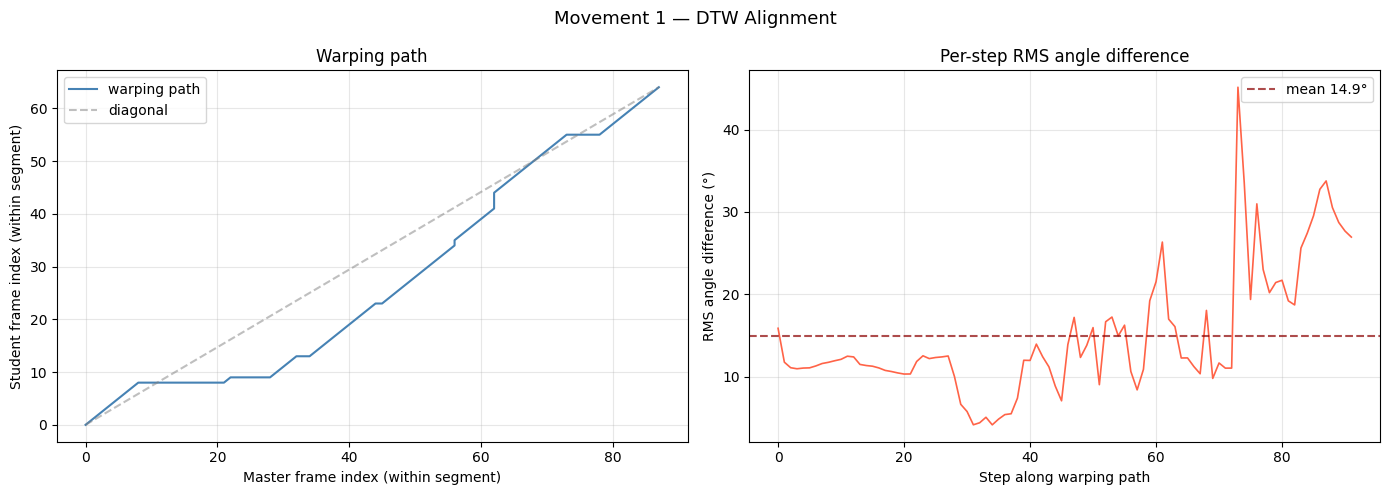

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Movement {mov} — DTW Alignment", fontsize=13)

# --- Left: warping path ---
ax = axes[0]
path_m = [p[0] for p in result.path]
path_s = [p[1] for p in result.path]
ax.plot(path_m, path_s, lw=1.5, color="steelblue", label="warping path")
diag_len = max(len(m_seg), len(s_seg))
ax.plot([0, len(m_seg)-1], [0, len(s_seg)-1], "--", color="gray", alpha=0.5, label="diagonal")
ax.set_xlabel("Master frame index (within segment)")
ax.set_ylabel("Student frame index (within segment)")
ax.set_title("Warping path")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: RMS difference along path ---
ax2 = axes[1]
rms_series = [fp.rms_diff for fp in result.frame_pairs]
ax2.plot(rms_series, color="tomato", lw=1.2)
ax2.axhline(result.mean_rms, color="darkred", linestyle="--", alpha=0.7,
            label=f"mean {result.mean_rms:.1f}°")
ax2.set_xlabel("Step along warping path")
ax2.set_ylabel("RMS angle difference (°)")
ax2.set_title("Per-step RMS angle difference")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

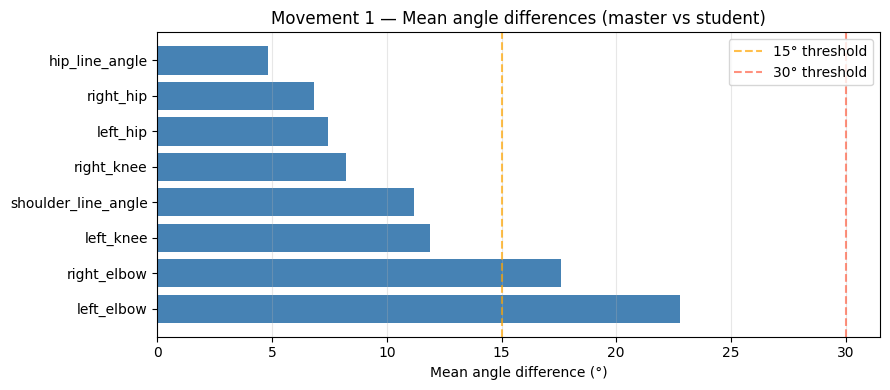


Angle mean differences:
  left_elbow               : 22.8°
  right_elbow              : 17.6°
  left_knee                : 11.9°
  shoulder_line_angle      : 11.2°
  right_knee               : 8.2°
  left_hip                 : 7.4°
  right_hip                : 6.8°
  hip_line_angle           : 4.8°


In [18]:
# Per-angle mean differences for VIZ_MOVEMENT
from collections import defaultdict

angle_sums: dict = defaultdict(float)
angle_counts: dict = defaultdict(int)
for fp in result.frame_pairs:
    for k, v in fp.angle_diffs.items():
        angle_sums[k] += v
        angle_counts[k] += 1

angle_means = {k: angle_sums[k] / angle_counts[k] for k in angle_sums}
sorted_keys = sorted(angle_means, key=lambda k: -angle_means[k])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(sorted_keys, [angle_means[k] for k in sorted_keys], color="steelblue")
ax.axvline(15, color="orange", linestyle="--", alpha=0.7, label="15° threshold")
ax.axvline(30, color="tomato", linestyle="--", alpha=0.7, label="30° threshold")
ax.set_xlabel("Mean angle difference (°)")
ax.set_title(f"Movement {mov} — Mean angle differences (master vs student)")
ax.legend()
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAngle mean differences:")
for k in sorted_keys:
    print(f"  {k:25s}: {angle_means[k]:.1f}°")

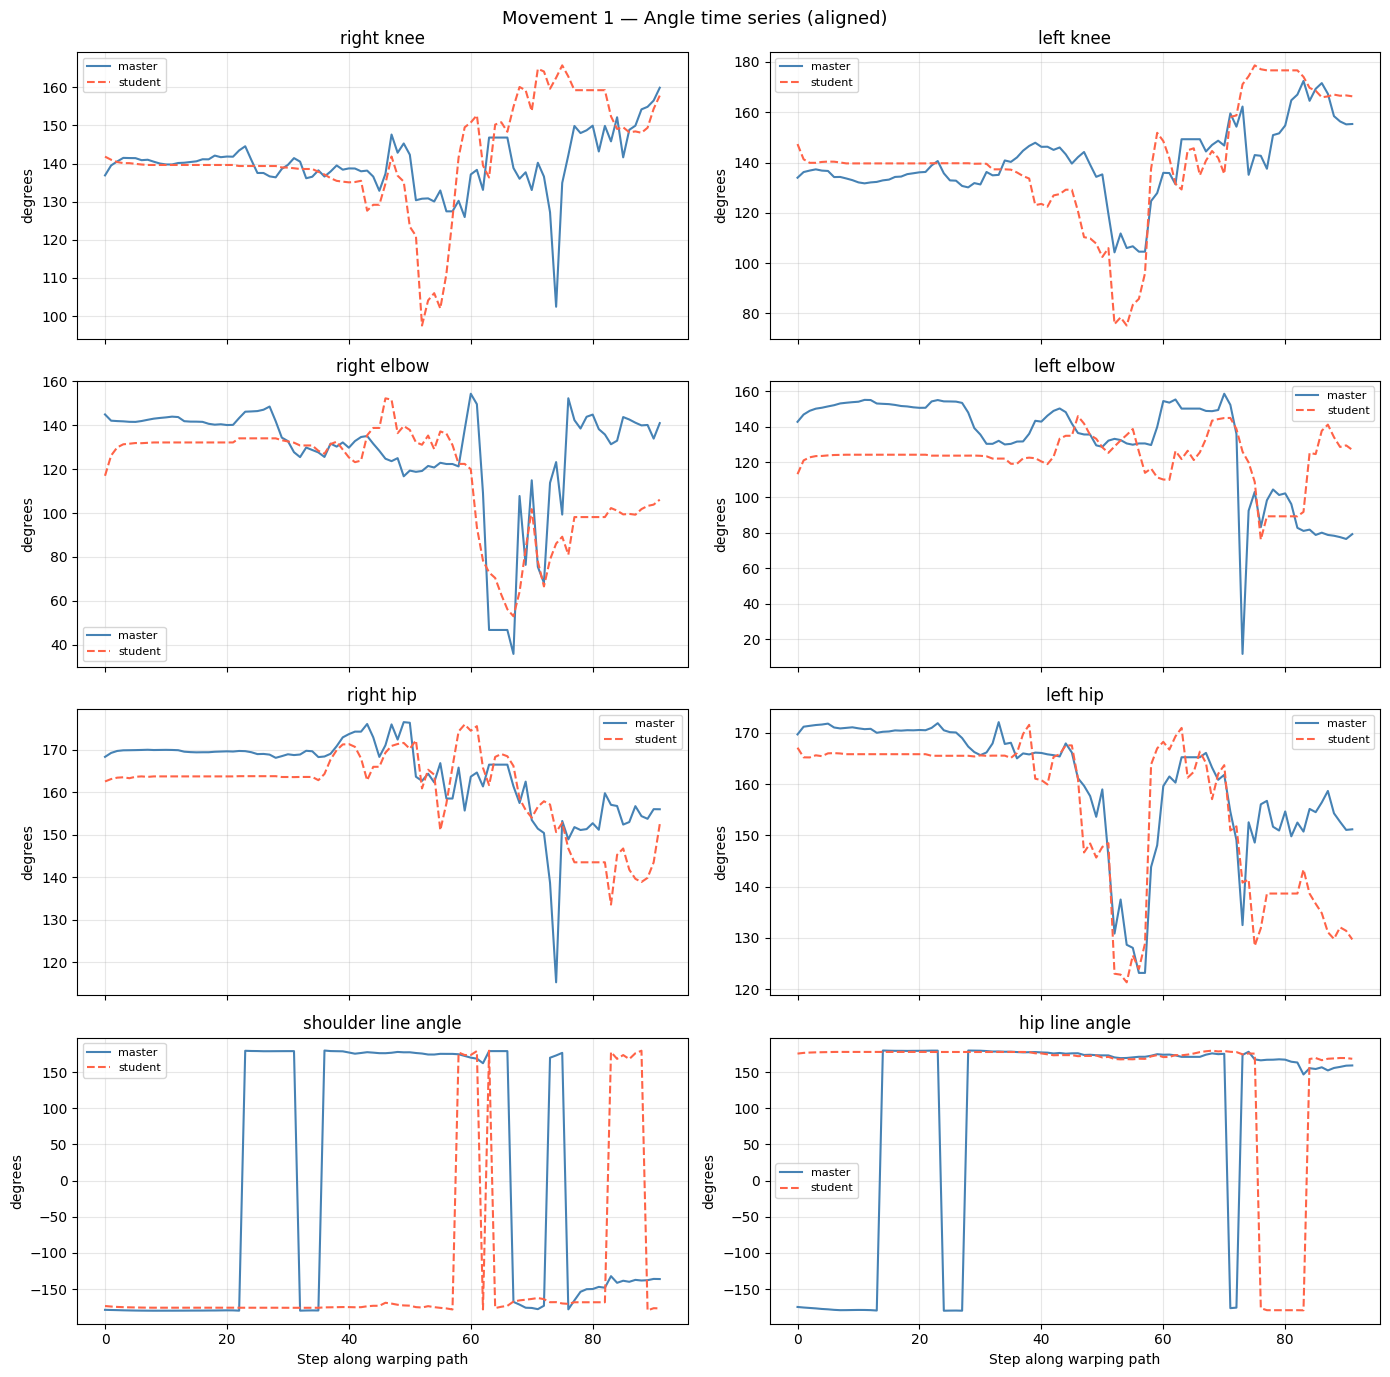

In [19]:
# Time series comparison for individual angles
ANGLE_KEYS = ["right_knee", "left_knee", "right_elbow", "left_elbow",
              "right_hip", "left_hip", "shoulder_line_angle", "hip_line_angle"]

master_ts = {k: [] for k in ANGLE_KEYS}
student_ts = {k: [] for k in ANGLE_KEYS}
path_steps = list(range(len(result.frame_pairs)))

for fp in result.frame_pairs:
    m_fa = dict(zip(
        [fi for fi, _ in m_seg],
        [fa for _, fa in m_seg]
    )).get(fp.master_frame, {})
    s_fa = dict(zip(
        [fi for fi, _ in s_seg],
        [fa for _, fa in s_seg]
    )).get(fp.student_frame, {})
    for k in ANGLE_KEYS:
        master_ts[k].append(m_fa.get(k, float('nan')))
        student_ts[k].append(s_fa.get(k, float('nan')))

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
fig.suptitle(f"Movement {mov} — Angle time series (aligned)", fontsize=13)

for ax, k in zip(axes.flat, ANGLE_KEYS):
    ax.plot(path_steps, master_ts[k], color="steelblue", lw=1.5, label="master")
    ax.plot(path_steps, student_ts[k], color="tomato", lw=1.5, linestyle="--", label="student")
    ax.set_title(k.replace("_", " "))
    ax.set_ylabel("degrees")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Step along warping path")
axes[-1, 1].set_xlabel("Step along warping path")
plt.tight_layout()
plt.show()

## Step 4 — Align all 19 movements

In [20]:
all_results = align_all_movements(master_segments, student_segments)
print(f"Aligned {len(all_results)} / 19 movements")
print()
print(f"{'Mov':>4} {'M-frames':>9} {'S-frames':>9} {'mean_rms':>10} {'max_rms':>9}")
print("-" * 48)
for mov_num in sorted(all_results):
    r = all_results[mov_num]
    m_n = len(master_segments.get(mov_num, []))
    s_n = len(student_segments.get(mov_num, []))
    print(f"{mov_num:>4} {m_n:>9} {s_n:>9} {r.mean_rms:>10.1f} {r.max_rms:>9.1f}")

Aligned 19 / 19 movements

 Mov  M-frames  S-frames   mean_rms   max_rms
------------------------------------------------
   1        88        65       14.9      45.1
   2        58        58       39.9      78.4
   3        57        54       25.6      76.1
   4        52        44       38.6      85.4
   5        56        69       31.3      72.9
   6        54        60       14.9      29.5
   7        53        64       23.3      39.3
   8        53        56       27.7      44.9
   9        58        58       24.1      41.0
  10        55        65       35.8      85.3
  11        60        62       32.6      82.9
  12        47        62       15.6      65.4
  13        54        60       23.7      66.4
  14        59        70       28.5      97.4
  15        52        59       23.1      49.7
  16        56        46       18.5      42.2
  17        51         8       19.5      26.5
  18        58         1       17.2      28.2
  19        62         1       20.7      32.0


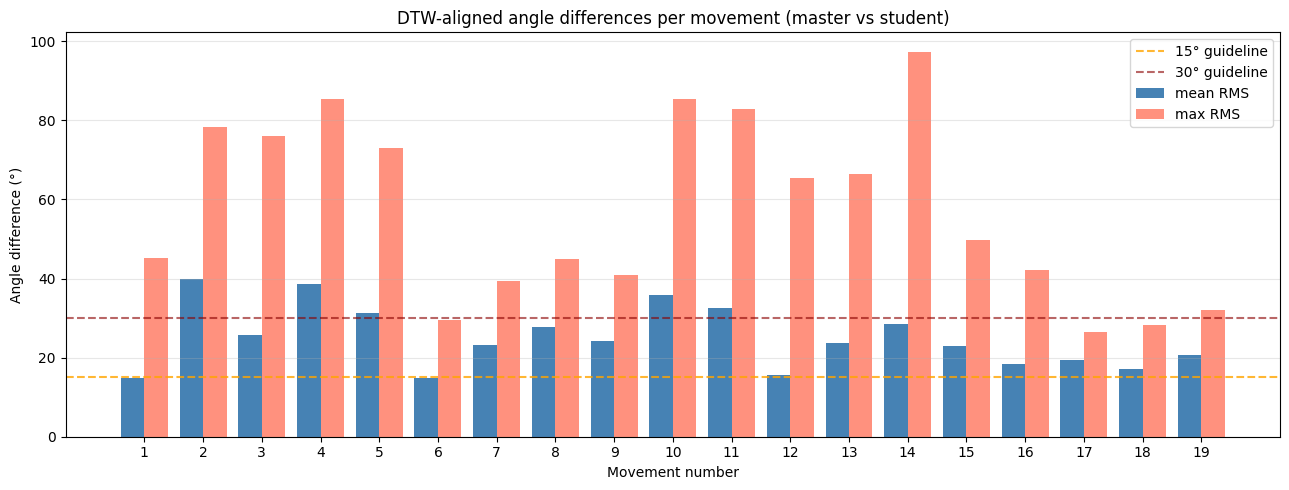

In [21]:
# Overview: mean RMS per movement
movs = sorted(all_results)
mean_rms_list = [all_results[m].mean_rms for m in movs]
max_rms_list  = [all_results[m].max_rms  for m in movs]

x = np.arange(len(movs))
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 0.2, mean_rms_list, width=0.4, label="mean RMS", color="steelblue")
ax.bar(x + 0.2, max_rms_list,  width=0.4, label="max RMS",  color="tomato", alpha=0.7)
ax.axhline(15, color="orange", linestyle="--", alpha=0.8, label="15° guideline")
ax.axhline(30, color="darkred", linestyle="--", alpha=0.6, label="30° guideline")
ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in movs])
ax.set_xlabel("Movement number")
ax.set_ylabel("Angle difference (°)")
ax.set_title("DTW-aligned angle differences per movement (master vs student)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

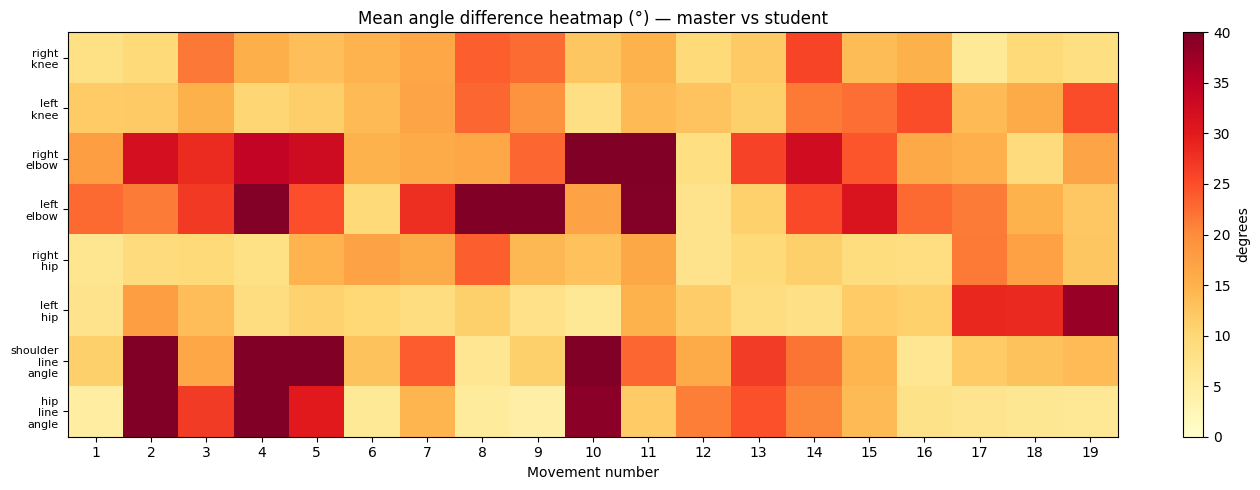

In [22]:
# Per-angle heatmap across all movements
ANGLE_KEYS = ["right_knee", "left_knee", "right_elbow", "left_elbow",
              "right_hip", "left_hip", "shoulder_line_angle", "hip_line_angle"]

from collections import defaultdict

heatmap = np.full((len(ANGLE_KEYS), len(movs)), np.nan)
for col, mov_num in enumerate(movs):
    r = all_results[mov_num]
    sums: dict = defaultdict(float)
    cnts: dict = defaultdict(int)
    for fp in r.frame_pairs:
        for k, v in fp.angle_diffs.items():
            sums[k] += v; cnts[k] += 1
    for row, k in enumerate(ANGLE_KEYS):
        if cnts[k]:
            heatmap[row, col] = sums[k] / cnts[k]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap, aspect="auto", cmap="YlOrRd", vmin=0, vmax=40)
ax.set_xticks(range(len(movs)))
ax.set_xticklabels([str(m) for m in movs])
ax.set_yticks(range(len(ANGLE_KEYS)))
ax.set_yticklabels([k.replace("_", "\n") for k in ANGLE_KEYS], fontsize=8)
ax.set_xlabel("Movement number")
ax.set_title("Mean angle difference heatmap (°) — master vs student")
plt.colorbar(im, ax=ax, label="degrees")
plt.tight_layout()
plt.show()

## Step 5 — Boundary frame verification

For each movement, computes the keypose distance between the **detected student boundary frame**
and the **stored master keypose angles**.

- If distance is low (< 20°): the segmenter found the right completion frame ✓  
- If distance is high (> 35°): the segmenter may have picked the wrong frame ✗ — check the overlay video

This is a sanity check on Layer 3 before trusting the Layer 4 angle differences.

In [ ]:
from itf_analysis.segmentation.keypose_matcher import keypose_distance

student_angle_lookup = {fi: fa for fi, fa in student_angles}
kp_map = {kp["movement_index"]: kp.get("angles", {}) for kp in keyposes}
boundary_map = {b.movement_number: b for b in student_boundaries}

rows = []
for mov_num in range(1, 20):
    b = boundary_map.get(mov_num)
    if b is None:
        rows.append((mov_num, None, "skipped", None, "SKIP"))
        continue
    fa = student_angle_lookup.get(b.frame, {})
    kp = kp_map.get(mov_num, {})
    if fa and kp:
        dist = keypose_distance(fa, kp)
        status = "✓" if dist < 20 else ("~" if dist < 35 else "✗")
        rows.append((mov_num, b.frame, b.confidence, dist, status))
    else:
        rows.append((mov_num, b.frame, b.confidence, None, "—"))

print(f"{'Mov':>4} {'Boundary':>9} {'Conf':>8} {'KP dist°':>9} {'OK?':>5}")
print("-" * 42)
for mov_num, bf, conf, dist, status in rows:
    bf_str = str(bf) if bf is not None else "—"
    dist_str = f"{dist:.1f}" if dist is not None else "—"
    print(f"{mov_num:>4} {bf_str:>9} {conf:>8} {dist_str:>9} {status:>5}")

bad = [r[0] for r in rows if r[4] == "✗"]
ok  = [r[0] for r in rows if r[4] == "✓"]
print(f"\n✓ verified ({len(ok)}): {ok}")
print(f"✗ re-check ({len(bad)}): {bad if bad else 'none'}")

In [ ]:
# Bar chart: all-movements keypose distance overview
kp_dists = [r[3] if r[3] is not None else 0.0 for r in rows]
bar_colors = ["tomato" if d > 35 else ("orange" if d > 20 else "steelblue") for d in kp_dists]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(1, 20), kp_dists, color=bar_colors)
ax.axhline(20, color="green",  linestyle="--", alpha=0.8, label="20° — good")
ax.axhline(35, color="tomato", linestyle="--", alpha=0.7, label="35° — re-check")
ax.set_xticks(range(1, 20))
ax.set_xlabel("Movement number")
ax.set_ylabel("Keypose distance at boundary frame (°)")
ax.set_title("Student boundary frame verification — keypose distance per movement")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Grouped bar chart: master keypose vs student at boundary frame for VIZ_MOVEMENT
b = boundary_map[VIZ_MOVEMENT]
fa_student_bound = student_angle_lookup.get(b.frame, {})
fa_master_kp = kp_map.get(VIZ_MOVEMENT, {})

common_keys = sorted(set(fa_student_bound) & set(fa_master_kp))
x = np.arange(len(common_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, [fa_master_kp[k] for k in common_keys], width,
       label="Master keypose", color="steelblue")
ax.bar(x + width/2, [fa_student_bound[k] for k in common_keys], width,
       label=f"Student boundary (frame {b.frame})", color="tomato", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([k.replace("_", "\n") for k in common_keys], fontsize=8)
ax.set_ylabel("degrees")
ax.set_title(f"Movement {VIZ_MOVEMENT} — Master keypose vs Student at boundary frame")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

# Annotate signed difference above each pair
CIRC = {"shoulder_line_angle", "hip_line_angle"}
for xi, k in enumerate(common_keys):
    delta = fa_student_bound.get(k, 0) - fa_master_kp.get(k, 0)
    if k in CIRC:
        delta = (delta + 180) % 360 - 180
    color = "red" if abs(delta) > 20 else "darkgreen"
    ypos = max(fa_master_kp.get(k, 0), fa_student_bound.get(k, 0)) + 4
    ax.text(xi, ypos, f"{delta:+.0f}°", ha="center", fontsize=8, color=color, fontweight="bold")

plt.tight_layout()
plt.show()
print(f"\nMovement {VIZ_MOVEMENT} boundary: frame={b.frame}  conf={b.confidence}")
dist_bound = keypose_distance(fa_student_bound, fa_master_kp)
print(f"Keypose distance at boundary: {dist_bound:.1f}°")